In [ ]:
# Настройка путей 
import sys
from pathlib import Path

# Получаем путь к корню проекта: поднимаемся из "Jupyter Notebooks/" на уровень выше
project_root = Path().resolve().parent

# Добавляем корень проекта в sys.path
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print(f"Project root added to sys.path: {project_root}")

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from datetime import datetime
from config import RAW_DATA_DIR
from src.db.queries import run_query


In [12]:
products = pd.DataFrame({
    'product_id': [1, 2, 3, 4],
    'name': ['Espresso', 'Latte', 'Cappuccino', 'Brownie'],
    'cost': [8, 18, 17, 35]
})

display(products)

sales = pd.DataFrame({
    'sale_id': [101, 102, 103, 104],
    'product_id': [1, 2, 3, 4],
    'quantity': [2, 5, 3, 4],
    'total_amount': [240, 1250, 690, 800]
})

display(sales)

,product_id,name,cost
0,1,Espresso,8
1,2,Latte,18
2,3,Cappuccino,17
3,4,Brownie,35


,sale_id,product_id,quantity,total_amount
0,101,1,2,240
1,102,2,5,1250
2,103,3,3,690
3,104,4,4,800


#### Объединение данных

In [13]:
df = sales.merge(products, on='product_id')
display(df)

,sale_id,product_id,quantity,total_amount,name,cost
0,101,1,2,240,Espresso,8
1,102,2,5,1250,Latte,18
2,103,3,3,690,Cappuccino,17
3,104,4,4,800,Brownie,35


#### Себестоимость и прибыль по строке


In [14]:
df['line_cost'] = df['cost'] * df['quantity']
df['line_profit'] = df['total_amount'] - df['line_cost']
df

,sale_id,product_id,quantity,total_amount,name,cost,line_cost,line_profit
0,101,1,2,240,Espresso,8,16,224
1,102,2,5,1250,Latte,18,90,1160
2,103,3,3,690,Cappuccino,17,51,639
3,104,4,4,800,Brownie,35,140,660


#### Агрегация данных

In [15]:
marginality = df.groupby('name').agg(
    revenue=('total_amount', 'sum'),
    cost=('line_cost', 'sum'),
    profit=('line_profit', 'sum')
).reset_index()

# Добавь маржинальность в %
marginality['margin_pct'] = (marginality['profit'] / marginality['revenue']) * 100
marginality['margin_pct'] = marginality['margin_pct'].round(2)

# Отсортируй по прибыли
marginality = marginality.sort_values('profit', ascending=False).reset_index(drop=True)

,name,revenue,cost,profit,margin_pct
0,Latte,1250,90,1160,92.80
1,Brownie,800,140,660,82.50
2,Cappuccino,690,51,639,92.61
3,Espresso,240,16,224,93.33


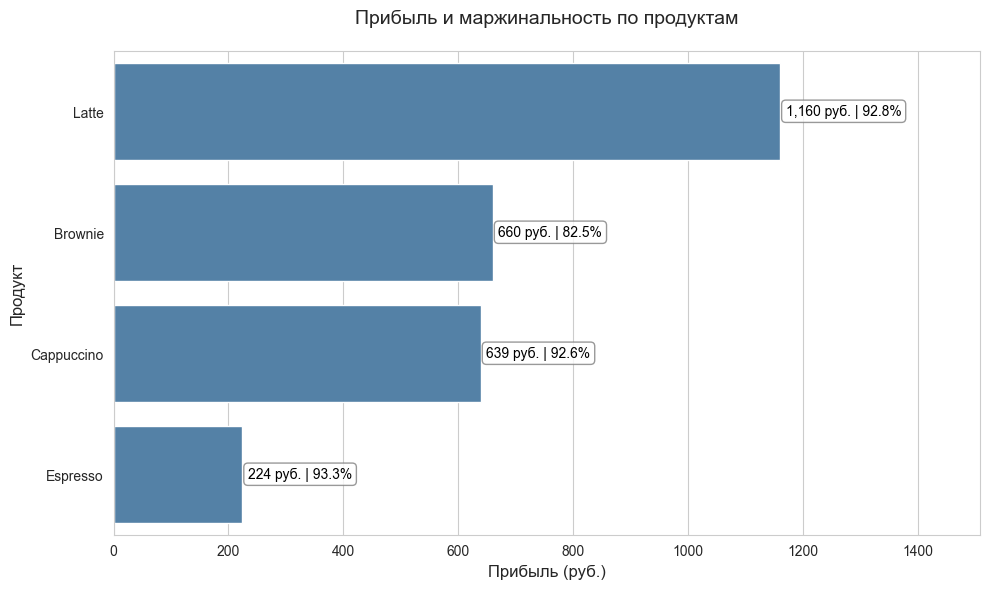

In [16]:
display(marginality)

# Убедимся, что индекс сброшен
marginality = marginality.reset_index(drop=True)

# Настройка стиля
sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))

# Строим график
ax = sns.barplot(data=marginality, x='profit', y='name', color='steelblue')

# Добавляем текст с динамическим отступом и фоном
for i in range(len(marginality)):
    profit = marginality.loc[i, 'profit']
    margin = marginality.loc[i, 'margin_pct']
    x_pos = profit + 10  # минимальный отступ
    
    ax.text(
        x_pos,
        i,
        f'{profit:,} руб. | {margin:.1f}%',
        va='center',
        fontsize=10,
        color='black',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray', alpha=0.8)
    )

# Расширяем ось X, чтобы текст не вылезал
ax.set_xlim(0, max(marginality['profit']) * 1.3)

# Оформление
plt.title('Прибыль и маржинальность по продуктам', fontsize=14, pad=20)
plt.xlabel('Прибыль (руб.)', fontsize=12)
plt.ylabel('Продукт', fontsize=12)
plt.tight_layout()
plt.show()

#### Сравнение выручки и среднего чека по дням. Сравнение количества чеков (трафика)

In [17]:
# Загрузка данных
df = pd.read_csv(RAW_DATA_DIR / "third_wave_coffee_shop.csv", parse_dates=['datetime', 'sale_date'])

In [18]:
# Агрегируем по дням (уникальные чеки!)
daily = (
    df.drop_duplicates('transaction_id')
    .groupby('sale_date')['total_cost']
    .sum()
    .sort_index()
    .reset_index(name='revenue')
)

# Добавляем выручку за предыдущий день
daily['prev_day_revenue'] = daily['revenue'].shift(1)

# Считаем % рост/падение
daily['revenue_change_pct'] = (daily['revenue'] - daily['prev_day_revenue']) / daily['prev_day_revenue'] * 100

daily['avg_check'] = (
    df.drop_duplicates('transaction_id')
    .groupby('sale_date')['total_cost']
    .mean()
    .values
)

daily['prev_avg_check'] = daily['avg_check'].shift(1)

# Сравнение количества чеков (трафика)
daily['n_transactions'] = (
    df.drop_duplicates('transaction_id')
    .groupby('sale_date')['transaction_id']
    .count()
    .values
)

daily['prev_n_transactions'] = daily['n_transactions'].shift(1)

display(daily)

,sale_date,revenue,prev_day_revenue,revenue_change_pct,avg_check,prev_avg_check,n_transactions,prev_n_transactions
0,2025-07-01,18640.0,NaN,NaN,454.634146,NaN,41,NaN
1,2025-07-02,17430.0,18640.0,-6.491416,458.684211,454.634146,38,41.0
2,2025-07-03,25150.0,17430.0,44.291452,474.528302,458.684211,53,38.0
3,2025-07-04,18410.0,25150.0,-26.799205,418.409091,474.528302,44,53.0
4,2025-07-05,18330.0,18410.0,-0.434546,509.166667,418.409091,36,44.0
...,...,...,...,...,...,...,...,...
87,2025-09-26,21030.0,18670.0,12.640600,467.333333,478.717949,45,39.0
88,2025-09-27,19740.0,21030.0,-6.134094,470.000000,467.333333,42,45.0
89,2025-09-28,16470.0,19740.0,-16.565350,422.307692,470.000000,39,42.0
90,2025-09-29,17960.0,16470.0,9.046752,438.048780,422.307692,41,39.0


In [19]:
daily['n_transactions'] = (
    df.drop_duplicates('transaction_id')
    .groupby('sale_date')['transaction_id']
    .count()
    .values
)

daily['prev_n_transactions'] = daily['n_transactions'].shift(1)

display(daily)

,sale_date,revenue,prev_day_revenue,revenue_change_pct,avg_check,prev_avg_check,n_transactions,prev_n_transactions
0,2025-07-01,18640.0,NaN,NaN,454.634146,NaN,41,NaN
1,2025-07-02,17430.0,18640.0,-6.491416,458.684211,454.634146,38,41.0
2,2025-07-03,25150.0,17430.0,44.291452,474.528302,458.684211,53,38.0
3,2025-07-04,18410.0,25150.0,-26.799205,418.409091,474.528302,44,53.0
4,2025-07-05,18330.0,18410.0,-0.434546,509.166667,418.409091,36,44.0
...,...,...,...,...,...,...,...,...
87,2025-09-26,21030.0,18670.0,12.640600,467.333333,478.717949,45,39.0
88,2025-09-27,19740.0,21030.0,-6.134094,470.000000,467.333333,42,45.0
89,2025-09-28,16470.0,19740.0,-16.565350,422.307692,470.000000,39,42.0
90,2025-09-29,17960.0,16470.0,9.046752,438.048780,422.307692,41,39.0


#### Сравнение популярности напитков (по дням или неделям)

In [20]:
# Пример: Raf coffee по дням
raf_daily = (
    df[df['coffee_name'] == 'Raf coffee']
    .groupby('sale_date')['transaction_id']
    .count()
    .rename('raf_count')
)

# Объединяем с общей статистикой
daily = daily.set_index('sale_date').join(raf_daily).reset_index()
daily['prev_raf_count'] = daily['raf_count'].shift(7)  # LAG на 7 дней

display(daily)

,sale_date,revenue,prev_day_revenue,revenue_change_pct,avg_check,prev_avg_check,n_transactions,prev_n_transactions,raf_count,prev_raf_count
0,2025-07-01,18640.0,NaN,NaN,454.634146,NaN,41,NaN,4.0,NaN
1,2025-07-02,17430.0,18640.0,-6.491416,458.684211,454.634146,38,41.0,2.0,NaN
2,2025-07-03,25150.0,17430.0,44.291452,474.528302,458.684211,53,38.0,11.0,NaN
3,2025-07-04,18410.0,25150.0,-26.799205,418.409091,474.528302,44,53.0,7.0,NaN
4,2025-07-05,18330.0,18410.0,-0.434546,509.166667,418.409091,36,44.0,6.0,NaN
...,...,...,...,...,...,...,...,...,...,...
87,2025-09-26,21030.0,18670.0,12.640600,467.333333,478.717949,45,39.0,3.0,5.0
88,2025-09-27,19740.0,21030.0,-6.134094,470.000000,467.333333,42,45.0,4.0,4.0
89,2025-09-28,16470.0,19740.0,-16.565350,422.307692,470.000000,39,42.0,3.0,3.0
90,2025-09-29,17960.0,16470.0,9.046752,438.048780,422.307692,41,39.0,2.0,4.0


#### Сравнение выручки в аналогичный день недели

In [26]:
# Группируем по неделе и дню недели
weekly = (
    df.drop_duplicates('transaction_id')
    .groupby(['day_of_week', pd.Grouper(key='sale_date', freq='W-MON')])['total_cost']
    .sum()
    .reset_index(name='weekly_dow_revenue')
)

# Сортируем и сдвигаем внутри каждого дня недели
weekly = weekly.sort_values(['day_of_week', 'sale_date'])
weekly['prev_week_revenue'] = weekly.groupby('day_of_week')['weekly_dow_revenue'].shift(1)

weekly.head(30)

,day_of_week,sale_date,weekly_dow_revenue,prev_week_revenue
0,1,2025-07-07,16660.0,NaN
1,1,2025-07-14,18250.0,16660.0
2,1,2025-07-21,17300.0,18250.0
3,1,2025-07-28,13050.0,17300.0
4,1,2025-08-04,16770.0,13050.0
5,1,2025-08-11,20520.0,16770.0
6,1,2025-08-18,19130.0,20520.0
7,1,2025-08-25,14400.0,19130.0
8,1,2025-09-01,21130.0,14400.0
9,1,2025-09-08,12560.0,21130.0
